
   
   
   



# Single-cell RNA-seq analysis of Drosophila L1 brain


**Single cell transcriptome atlas of the Drosophila larval brain**

Clarisse Brunet Avalos, G Larisa Maier, Rémy Bruggmann, Simon G Sprecher

10x Genomics scRNA-seq

👉 4708 cells  
👉 17493 genes  


   https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE134722

    - GSE134722_FirstInstarLarvalBrainNormalCondition_finalaggr_10X_matrix.mtx.gz
    - GSE134722_FirstInstarLarvalBrainNormalCondition_finalaggr_10X_genes.tsv.gz
    - GSE134722_FirstInstarLarvalBrainNormalCondition_finalaggr_10X_barcodes.tsv.gz  

    saved to /Volumes/lab-windingm/home/users/cochral/PhD/NDD/GENE-EXPRESSION/L1-DATASET/dataset







### Load Dataset and Build AnnData Object:


In [2]:
import pandas as pd
import numpy as np
import scanpy as sc  # standard library for single-cell analysis
import gzip # opens .gz compressed files
from scipy.io import mmread
from scipy.sparse import csr_matrix # sparse matrix format for efficient storage of data
from anndata import AnnData # AnnData = a single-cell dataset structure
import seaborn as sns
import matplotlib.pyplot as plt
import os

save_dir = "/Volumes/lab-windingm/home/users/cochral/PhD/NDD/GENE-EXPRESSION/L1-DATASET"
data_dir = "/Volumes/lab-windingm/home/users/cochral/PhD/NDD/GENE-EXPRESSION/L1-DATASET/dataset"

matrix_file = f"{data_dir}/GSE134722_FirstInstarLarvalBrainNormalCondition_finalaggr_10X_matrix.mtx.gz" # expression counts = matrix of numbers
genes_file = f"{data_dir}/GSE134722_FirstInstarLarvalBrainNormalCondition_finalaggr_10X_genes.tsv.gz" # gene IDs = rows
barcodes_file = f"{data_dir}/GSE134722_FirstInstarLarvalBrainNormalCondition_finalaggr_10X_barcodes.tsv.gz" # cells = columns


# read count matrix 
with gzip.open(matrix_file, "rb") as f:
    X = mmread(f).tocsr().T 

# read genes
with gzip.open(genes_file, "rt") as f:
    genes = [line.strip().split("\t") for line in f]

# separate gene IDs and symbols
gene_ids = [g[0] for g in genes]
gene_symbols = [g[1] for g in genes]

# read barcodes
with gzip.open(barcodes_file, "rt") as f:
    barcodes = [line.strip() for line in f]

# build AnnData object
adata = AnnData(
    X=csr_matrix(X), # expression matrix
    obs=pd.DataFrame(index=barcodes), # observations=cells metadata (add to later)
    var=pd.DataFrame( # variables=gene metadata
        {
            "gene_ids": gene_ids,
            "gene_symbols": gene_symbols
        },
        index=gene_symbols
    )
)

# make duplicate gene names unique if needed
adata.var_names_make_unique()

adata_raw_counts = adata.copy()

# normalize so each cell have the same total expression
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

adata.raw = adata.copy()

adata
adata.shape
adata.obs.head()
adata.var.head()


,gene_ids,gene_symbols
Prosalpha2,FBgn0086134,Prosalpha2
lncRNA:CR45913,FBgn0267573,lncRNA:CR45913
CG6724,FBgn0032298,CG6724
CG6660,FBgn0039030,CG6660
Tsf3,FBgn0034094,Tsf3


### Load Genes of Interest:

In [3]:
genes_of_interest = [
    'bel',
    "Nrx-1",
    "para", 
    "Atg17", 
    "Cul1",
    "GluRIA", 
    "Prosap", 
    "Syx1A", 
    "Nmdar2",
    "dlg1", 
    "kis", 
    "p120ctn", 
    "Pp2C1",
    "trio", 
    "ctrip", 
    "Ca-alpha1T", 
    "Iml1",
    "lid", 
    'Set1',
    "raskol",
    # 'mnb'
]

# raskol is missing
missing = [g for g in genes_of_interest if g not in adata.var_names]
print("Missing:", missing)

# remove missing genes
genes_of_interest = [g for g in genes_of_interest if g in adata.var_names]

Missing: ['raskol']


### Expression Summary Across All Cells:

In [4]:

## Expression Summary Across All Cells

output_dir = os.path.join(save_dir, 'expression_summary')
os.makedirs(output_dir, exist_ok=True)

summary = []

for gene in genes_of_interest:
    x = adata[:, gene].X

    # convert sparse column to a flat numpy array
    x = x.toarray().flatten()

    n_cells = (x > 0).sum()
    frac_cells = n_cells / len(x)
    mean_all_cells = x.mean()
    mean_expressing_cells = x[x > 0].mean() if n_cells > 0 else 0

    summary.append({
        "gene": gene,
        "n_cells_expressing": int(n_cells),
        "fraction_cells_expressing": frac_cells,
        "mean_expression_all_cells": mean_all_cells,
        "mean_expression_in_expressing_cells": mean_expressing_cells
    })

summary_df = pd.DataFrame(summary)
summary_df.to_csv(f"{output_dir}/all_cells_expression_summary.csv", index=False)



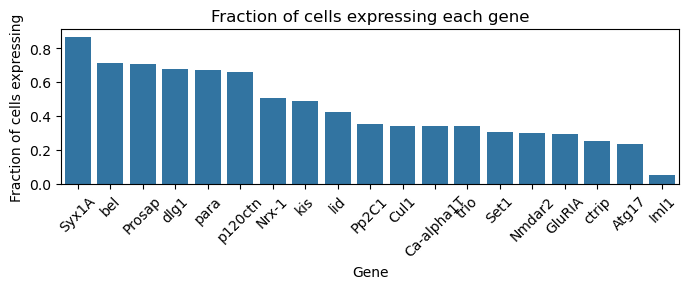

In [5]:
## Plot fraction of cells expressing each gene

summary_df = summary_df.sort_values("fraction_cells_expressing", ascending=False)

plt.figure(figsize=(7, 3))
sns.barplot(
    data=summary_df,
    x="gene",
    y="fraction_cells_expressing"
)

plt.xticks(rotation=45)
plt.ylabel("Fraction of cells expressing")
plt.xlabel("Gene")
plt.title("Fraction of cells expressing each gene")

plt.tight_layout()
plt.savefig(f"{output_dir}/fraction_cells_expressing.png", dpi=300)
plt.show()

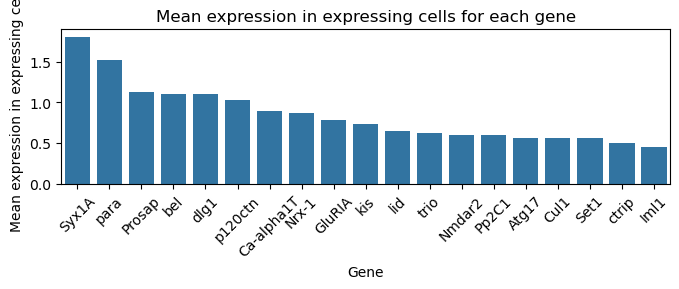

In [6]:
## Plot fraction of cells expressing each gene

summary_df = summary_df.sort_values("mean_expression_in_expressing_cells", ascending=False)

plt.figure(figsize=(7, 3))
sns.barplot(
    data=summary_df,
    x="gene",
    y="mean_expression_in_expressing_cells"
)

plt.xticks(rotation=45)
plt.ylabel("Mean expression in expressing cells")
plt.xlabel("Gene")
plt.title("Mean expression in expressing cells for each gene")

plt.tight_layout()
plt.savefig(f"{output_dir}/mean_expression_in_expressing_cells.png", dpi=300)
plt.show()

### Binary Gene Co-Expression Analysis Across All Cells

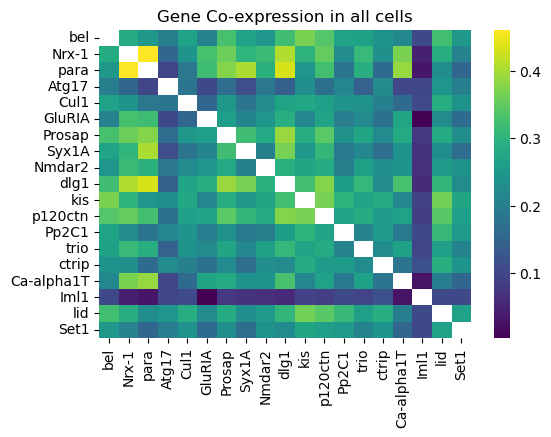

In [7]:
binary = {}

for gene in genes_of_interest:
    x = adata[:, gene].X.toarray().flatten()
    binary[gene] = (x > 0).astype(int)

binary_df = pd.DataFrame(binary)
binary_df.to_csv(f"{output_dir}/binary_matrix.csv", index=False)

corr = binary_df.corr() # compute pairwise correlation between genes based on binary expression

corr_no_diag = corr.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)


plt.figure(figsize=(6, 4))
sns.heatmap(corr_no_diag, cmap="viridis")
plt.title("Gene Co-expression in all cells")
plt.savefig(f"{output_dir}/correlation_heatmap.png")
plt.show()


### Summarise Gene Expression within Cell Types  

elav → neurons  
repo → glia  
dpn → progenitors  


In [8]:

## Expression Summary Within Cell Types

output_dir = os.path.join(save_dir, 'expression_summary_by_cell_type')
os.makedirs(output_dir, exist_ok=True)

# broad cell-type markers
elav = adata[:, "elav"].X.toarray().flatten()
repo = adata[:, "repo"].X.toarray().flatten()
dpn  = adata[:, "dpn"].X.toarray().flatten()

cell_type = []

for i in range(adata.n_obs):
    if elav[i] > 0:
        cell_type.append("neuron")
    elif repo[i] > 0:
        cell_type.append("glia")
    elif dpn[i] > 0:
        cell_type.append("progenitor")
    else:
        cell_type.append("unknown")

adata.obs["cell_type"] = cell_type

print(adata.obs["cell_type"].value_counts())

neuron        3078
unknown       1393
progenitor     162
glia            75
Name: cell_type, dtype: int64


In [9]:
results = []

cell_types = ["neuron", "glia", "progenitor", "unknown"]

for gene in genes_of_interest:
    gene_all = adata[:, gene].X.toarray().flatten()
    total_gene_positive = (gene_all > 0).sum()

    for ct in cell_types:
        mask = adata.obs["cell_type"] == ct
        x = adata[mask, gene].X.toarray().flatten()

        n_cells_in_type = len(x)
        n_gene_positive_in_type = (x > 0).sum()

        results.append({
            "gene": gene,
            "cell_type": ct,
            "within_cell_type_fraction": n_gene_positive_in_type / n_cells_in_type if n_cells_in_type > 0 else 0, # e.g. within all neurons what fraction express this gene
            "gene_expression_distribution": n_gene_positive_in_type / total_gene_positive if total_gene_positive > 0 else 0, # e.g. of all cells expressing this gene, what fraction are neurons
            "mean_expression_all_cells": x.mean(),
            "mean_expression_in_expressing_cells": x[x > 0].mean() if n_gene_positive_in_type > 0 else 0
        })


results_df = pd.DataFrame(results)
results_df.to_csv(f"{output_dir}/genes_of_interest_by_cell_type.csv", index=False)
results_df

,gene,cell_type,within_cell_type_fraction,gene_expression_distribution,mean_expression_all_cells,mean_expression_in_expressing_cells
0,bel,neuron,0.834633,0.764583,0.888042,1.063991
1,bel,glia,0.586667,0.013095,0.513017,0.874460
2,bel,progenitor,0.611111,0.029464,0.637489,1.043165
3,bel,unknown,0.465183,0.192857,0.600231,1.290312
4,Nrx-1,neuron,0.641650,0.832631,0.508907,0.793122
...,...,...,...,...,...,...
71,lid,unknown,0.170854,0.119598,0.179985,1.053444
72,Set1,neuron,0.395712,0.851153,0.193764,0.489659
73,Set1,glia,0.146667,0.007687,0.056768,0.387053
74,Set1,progenitor,0.222222,0.025157,0.117881,0.530464


### Within Cell Type how Common is Gene:  

e.g. within neurons how common is gene x

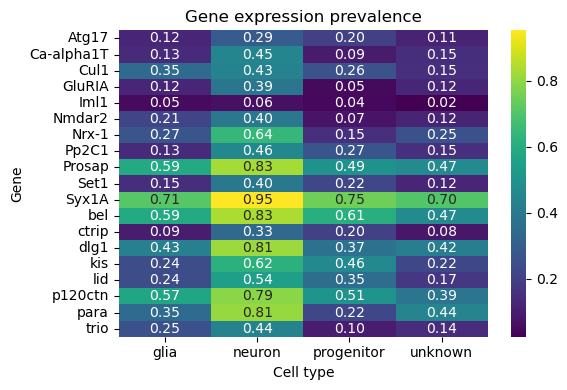

In [10]:

frac_celltype_plot = results_df.pivot(
    index="gene",
    columns="cell_type",
    values="within_cell_type_fraction"
)

plt.figure(figsize=(6, 4))
sns.heatmap(frac_celltype_plot, cmap="viridis", annot=True, fmt=".2f")
plt.title("Gene expression prevalence")
plt.xlabel("Cell type")
plt.ylabel("Gene")
plt.tight_layout()
plt.savefig(f"{output_dir}/gene_expression_prevalence.png", dpi=300)
plt.show()

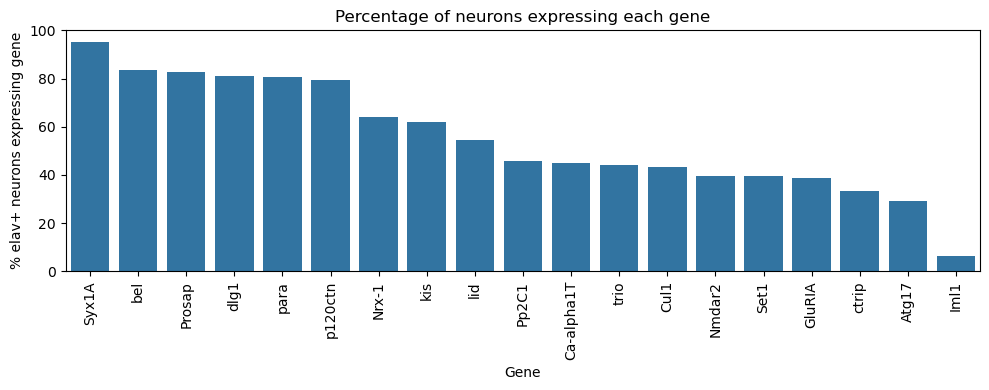

In [11]:
# Barplot: % of neurons (elav+) expressing each gene
neuron_df = results_df[results_df["cell_type"] == "neuron"].copy()
neuron_df["percent_neurons_expressing"] = neuron_df["within_cell_type_fraction"] * 100

neuron_df = neuron_df.sort_values("percent_neurons_expressing", ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=neuron_df,
    x="gene",
    y="percent_neurons_expressing"
)

plt.xticks(rotation=90)
plt.ylabel("% elav+ neurons expressing gene")
plt.xlabel("Gene")
plt.title("Percentage of neurons expressing each gene")
plt.tight_layout()
plt.savefig(f"{output_dir}/percent_elav_positive_neurons_expressing_each_gene.pdf", format="pdf")
plt.show()

### Distribution of Expressing Cells  

e.g. Where are the cells which express this gene?

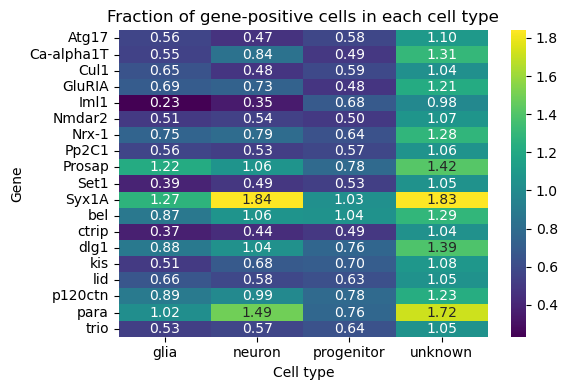

In [12]:
# 2. Fraction of gene-positive cells belonging to each cell type
frac_gene_plot = results_df.pivot(
    index="gene",
    columns="cell_type",
    values="mean_expression_in_expressing_cells"
)

plt.figure(figsize=(6, 4))
sns.heatmap(frac_gene_plot, cmap="viridis", annot=True, fmt=".2f")
plt.title("Fraction of gene-positive cells in each cell type")
plt.xlabel("Cell type")
plt.ylabel("Gene")
plt.tight_layout()
plt.savefig(f"{output_dir}/distribution_within_expressing_cells.png", dpi=300)
plt.show()


### Mean Expression within Expressing Cells  

e.g how much expression within cells which express the gene



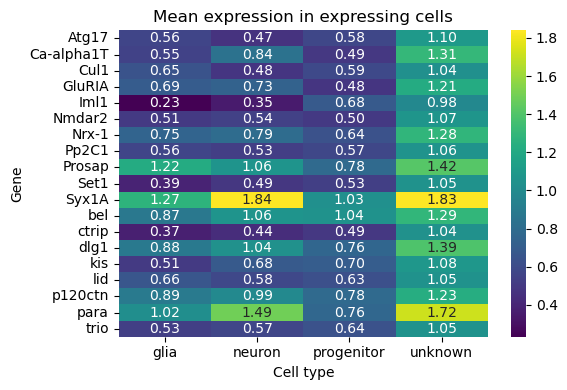

In [13]:
mean_expr_plot = results_df.pivot(
    index="gene",
    columns="cell_type",
    values="mean_expression_in_expressing_cells"
)

plt.figure(figsize=(6, 4))
sns.heatmap(mean_expr_plot, cmap="viridis", annot=True, fmt=".2f")
plt.title("Mean expression in expressing cells")
plt.xlabel("Cell type")
plt.ylabel("Gene")
plt.tight_layout()
plt.savefig(f"{output_dir}/expression_in_expressing_cells.png", dpi=300)
plt.show()


### Cluster Neuron Cell Types and Observe Gene Expression  

Subset Neurons from raw dataset. Then normalise counts within neurons (apparently necessary for clustering?).

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


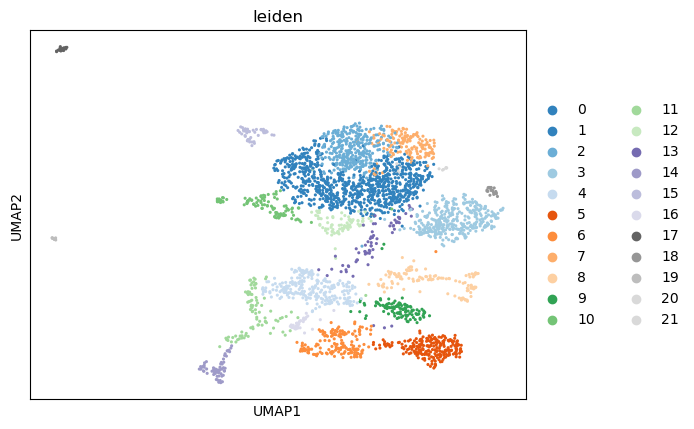

In [14]:
output_dir = os.path.join(save_dir, "neuron_analysis")
os.makedirs(output_dir, exist_ok=True)

# apply the same cell type annotation to the raw counts data
adata_raw_counts.obs["cell_type"] = adata.obs["cell_type"].copy()

# subset neurons from RAW counts
neuron_mask = adata_raw_counts.obs["cell_type"] == "neuron"
adata_neurons = adata_raw_counts[neuron_mask].copy()

# now normalize the neuron-only subset
sc.pp.normalize_total(adata_neurons)
sc.pp.log1p(adata_neurons)

# save full normalized neuron matrix for gene plotting later
adata_neurons.raw = adata_neurons.copy()

# use variable genes for clustering
sc.pp.highly_variable_genes(adata_neurons, n_top_genes=2000)
adata_neurons = adata_neurons[:, adata_neurons.var.highly_variable].copy()

# dimensionality reduction + clustering
sc.pp.pca(adata_neurons)
sc.pp.neighbors(adata_neurons)
sc.tl.leiden(adata_neurons)
sc.tl.umap(adata_neurons)

# plot clusters
sc.pl.umap(adata_neurons, color="leiden", show=False, size=20, palette="tab20c")
plt.savefig(f"{output_dir}/umap_leiden.png", dpi=300)
plt.show()


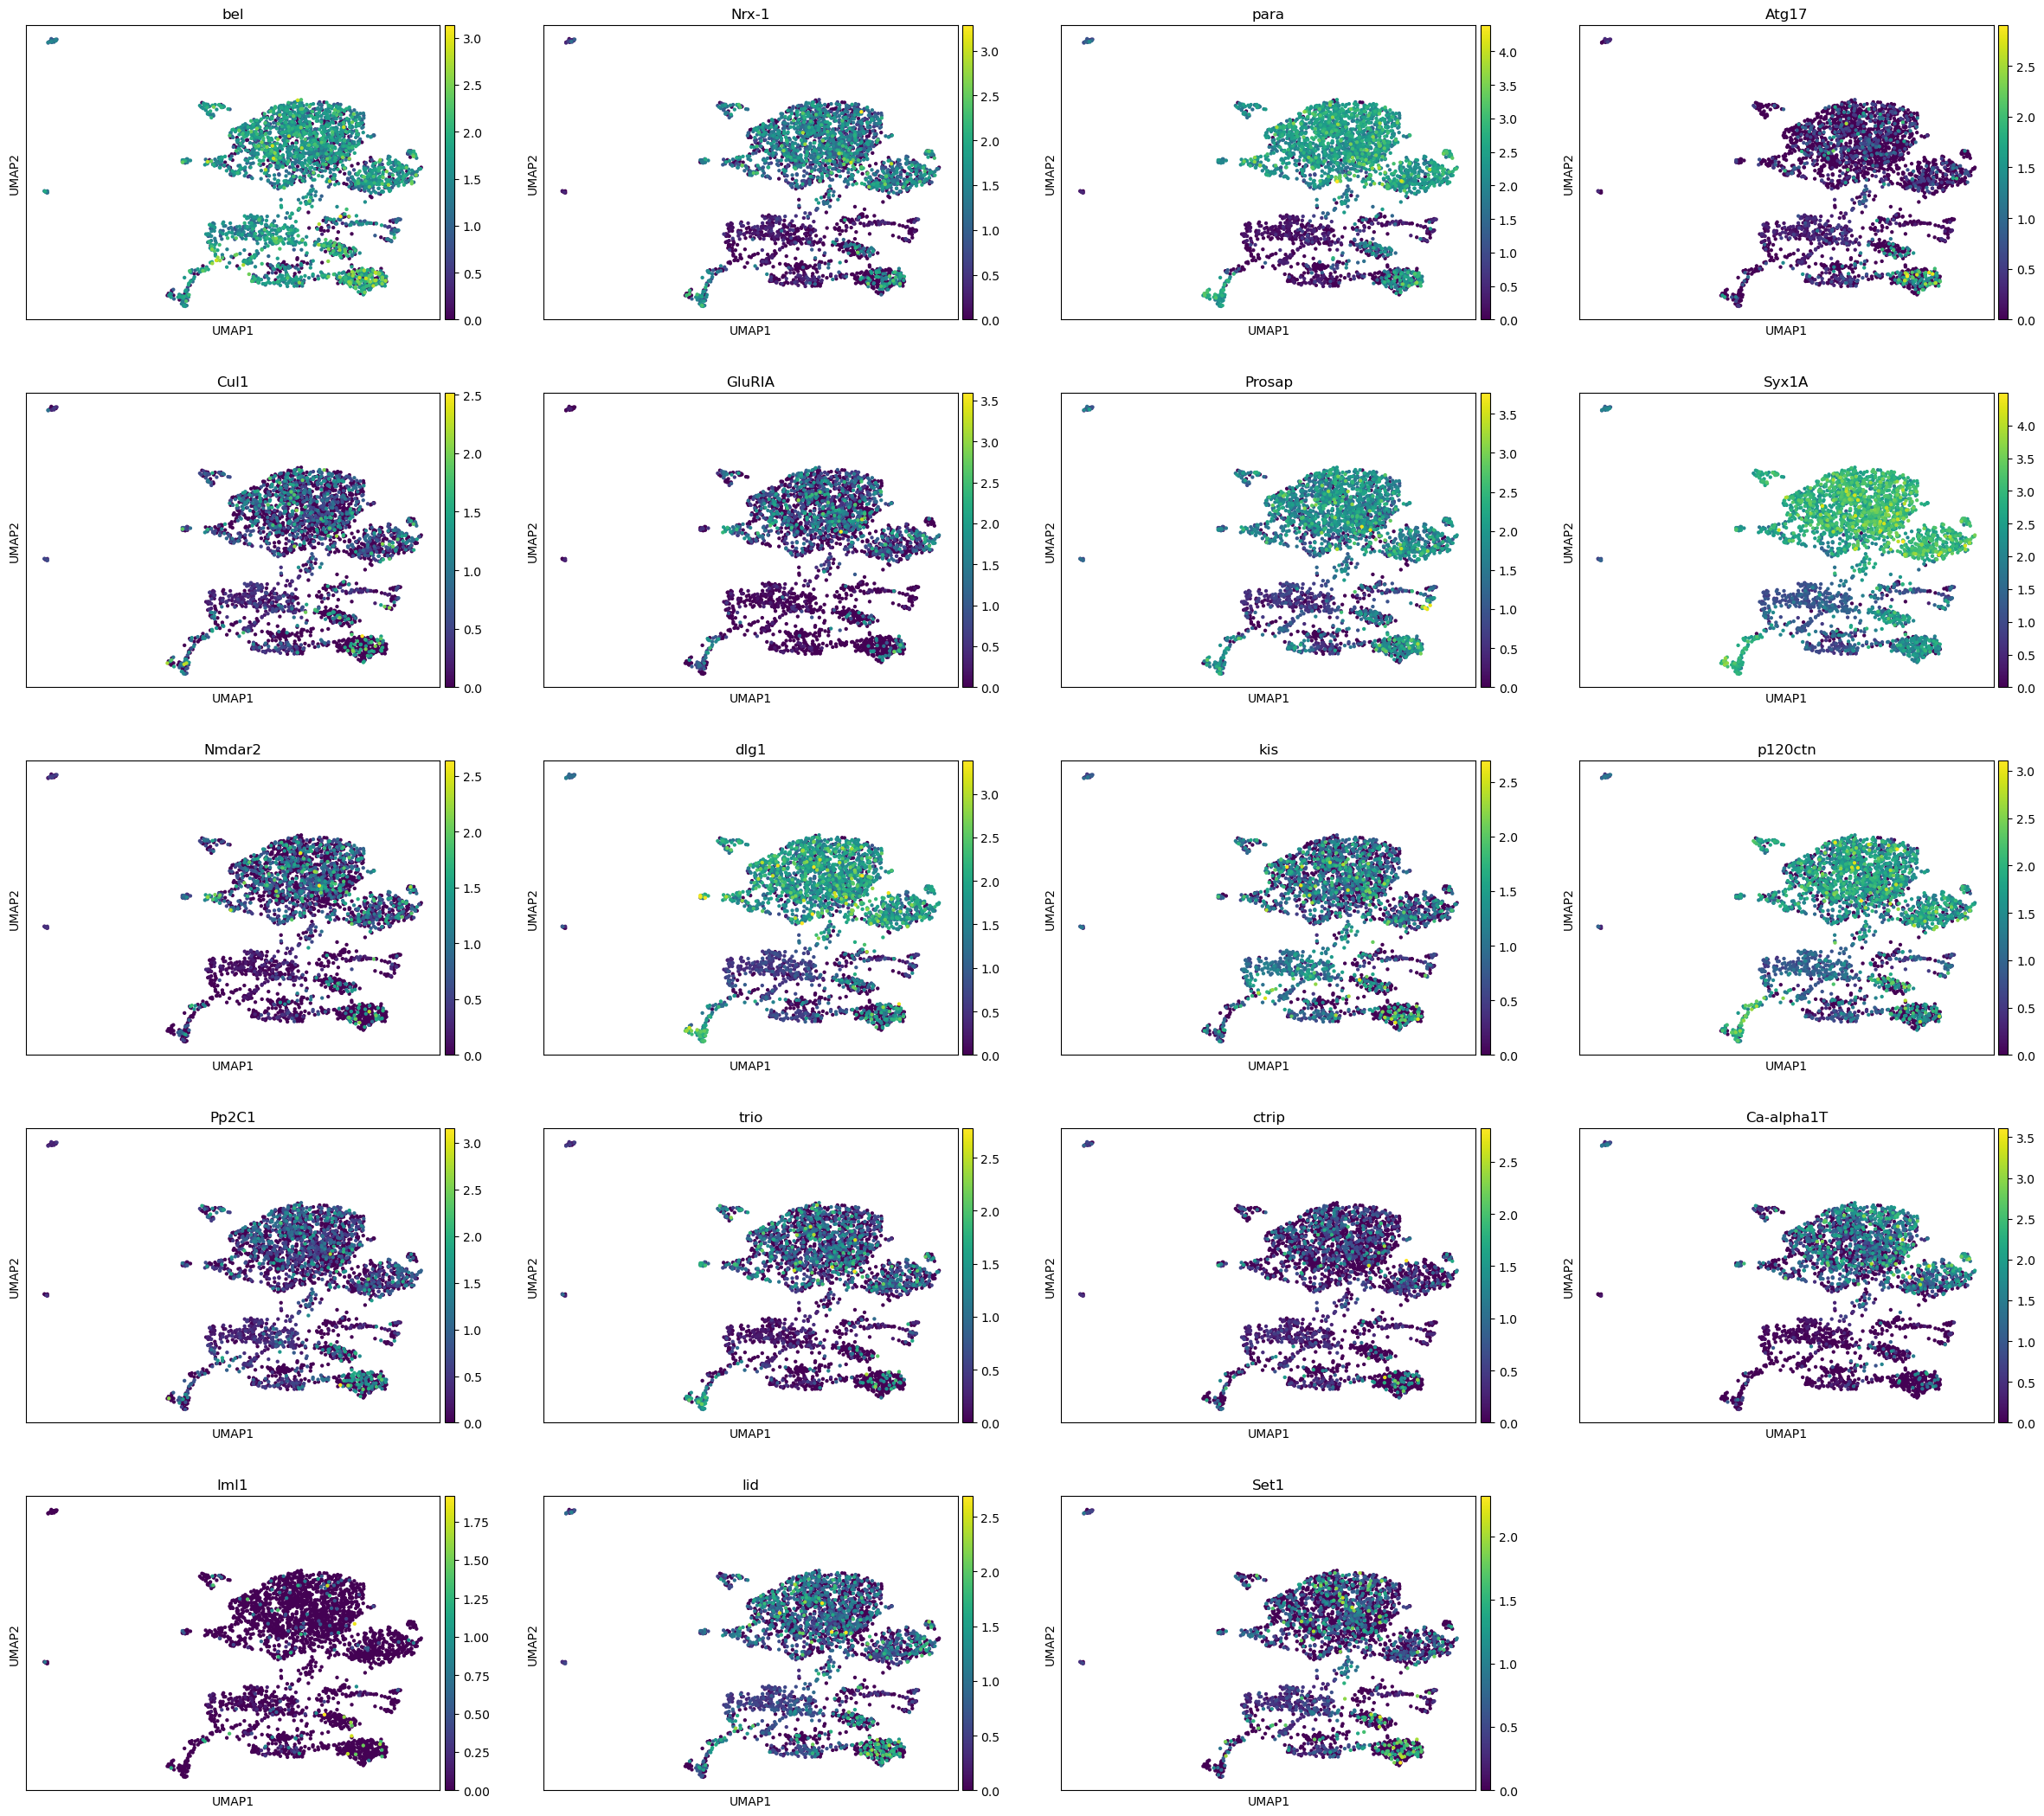

In [15]:
sc.pl.umap(
    adata_neurons,
    color=genes_of_interest,
    use_raw=True,   # 🔥 THIS is the key
    show=False
)

plt.savefig(f"{save_dir}/umap_genes_of_interest.png", dpi=300, bbox_inches="tight")
plt.show()

### Neurotransmitter Based Neuron Subtypes and Observe Gene Expression  

ChAT → cholinergic  
Gad1 → GABAergic  
VGlut → glutamatergic  
ple -> dopamine (Tyrosine Hydroxylase (TH))  
Trh -> serotenergic


In [16]:
## Identify subtypes based on neurotransmitter markers

ChAT = adata[:, "ChAT"].X.toarray().flatten()
VGlut = adata[:, "VGlut"].X.toarray().flatten()
Gad1 = adata[:, "Gad1"].X.toarray().flatten()

ple = adata[:, "ple"].X.toarray().flatten()      # dopamine
# Trh = adata[:, "Trh"].X.toarray().flatten()      # serotonin
# Tdc2 = adata[:, "Tdc2"].X.toarray().flatten()    # tyramine/octopamine
# Tbh = adata[:, "Tbh"].X.toarray().flatten()      # octopamine


subtype = []

for i in range(adata.n_obs):
    labels = []

    if ChAT[i] > 0:
        labels.append("cholinergic")
    if Gad1[i] > 0:
        labels.append("GABAergic")
    if VGlut[i] > 0:
        labels.append("glutamatergic")

    # monoamines
    if ple[i] > 0:
        labels.append("dopaminergic")

    # if Trh[i] > 0:
    #     labels.append("serotonergic")

    # # group tyramine + octopamine together
    # if Tdc2[i] > 0 or Tbh[i] > 0:
    #     labels.append("octopaminergic")

    # fallback
    if len(labels) == 0:
        labels.append("other")

    # join labels into a single string
    subtype.append("_".join(labels))

adata.obs["neuron_subtype_marker_based"] = subtype

In [17]:
## Identify neuron subtypes based on neurotransmitter markers

neuron_data = adata[adata.obs["cell_type"] == "neuron"].copy()

subtypes = neuron_data.obs["neuron_subtype_marker_based"].unique()

results_subtype = []

for gene in genes_of_interest:
    gene_all = neuron_data[:, gene].X.toarray().flatten()
    total_gene_positive = (gene_all > 0).sum()

    for st in subtypes:
        mask = neuron_data.obs["neuron_subtype_marker_based"] == st
        x = neuron_data[mask, gene].X.toarray().flatten()

        n_cells_in_subtype = len(x)
        n_gene_positive_in_subtype = (x > 0).sum()

        results_subtype.append({
            "gene": gene,
            "subtype": st,
            "within_subtype": n_gene_positive_in_subtype / n_cells_in_subtype if n_cells_in_subtype > 0 else 0,
            "gene_distribution": n_gene_positive_in_subtype / total_gene_positive if total_gene_positive > 0 else 0,
            "mean_expression_all_cells": x.mean(),
            "mean_expression_in_expressing_cells": x[x > 0].mean() if n_gene_positive_in_subtype > 0 else 0
        })


results_subtype_df = pd.DataFrame(results_subtype)
results_subtype_df.to_csv(f"{save_dir}/genes_of_interest_by_marker_based_subtype.csv", index=False)
print(results_subtype_df)

     gene                                           subtype  within_subtype  \
0     bel                                     glutamatergic        0.803738   
1     bel                                             other        0.616368   
2     bel               cholinergic_GABAergic_glutamatergic        0.970455   
3     bel                         cholinergic_glutamatergic        0.913495   
4     bel                                       cholinergic        0.740984   
..    ...                                               ...             ...   
299  Set1  cholinergic_GABAergic_glutamatergic_dopaminergic        0.770833   
300  Set1                          cholinergic_dopaminergic        0.526316   
301  Set1                                      dopaminergic        0.217391   
302  Set1                            GABAergic_dopaminergic        0.285714   
303  Set1              GABAergic_glutamatergic_dopaminergic        0.772727   

     gene_distribution  mean_expression_all_cells  

### Within Neurotransmitter Cell Type how Common is Gene:  

e.g. within glutamatergic neurons how common is gene x

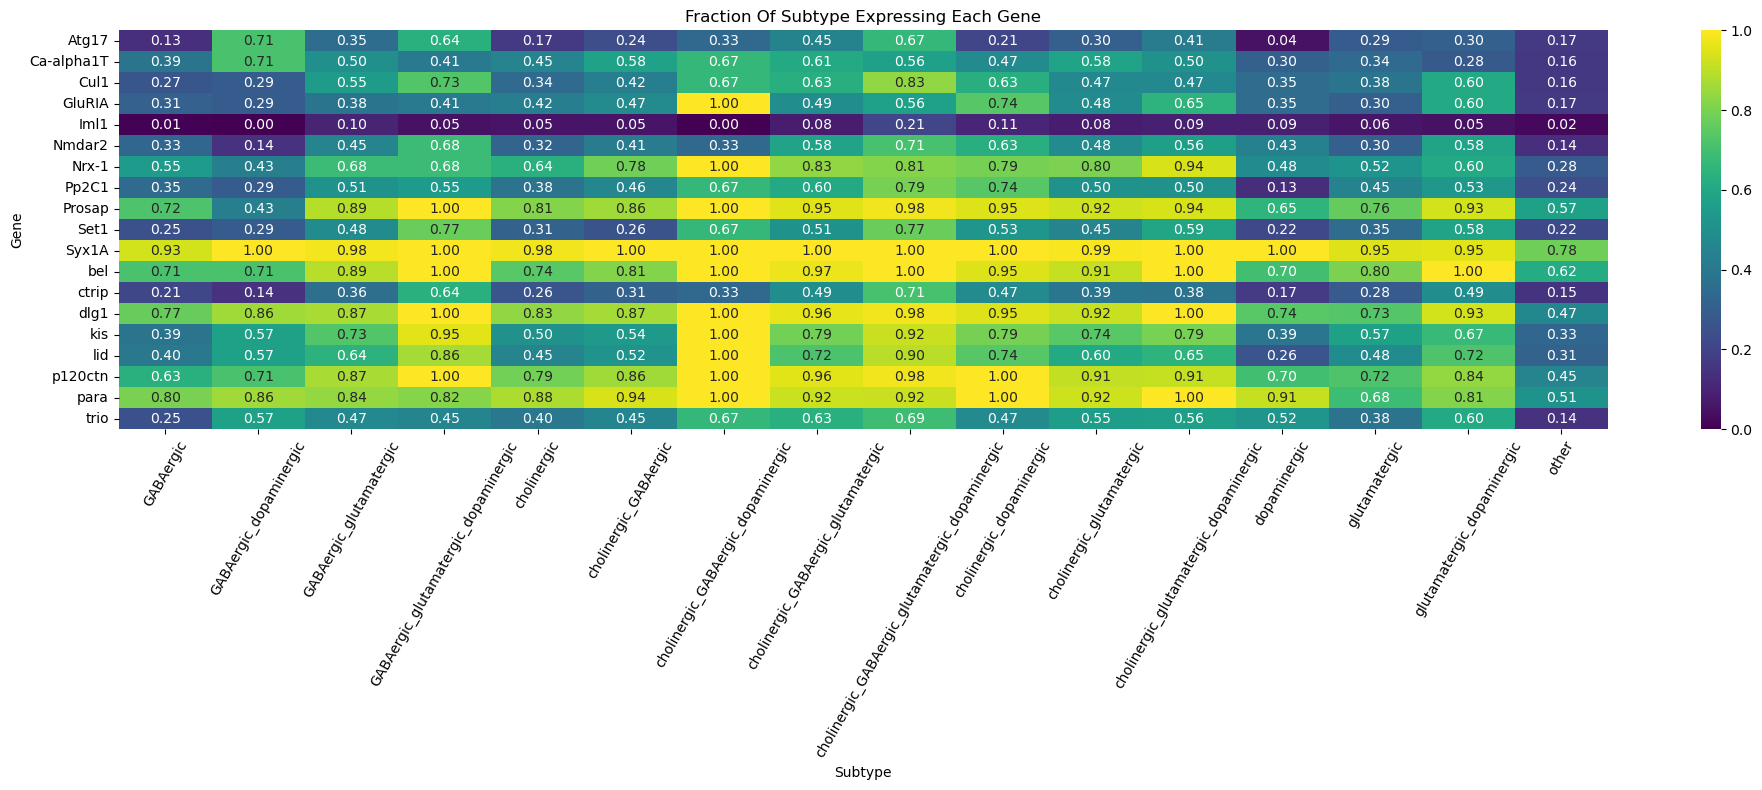

In [18]:
# 1. Fraction of each subtype expressing each gene
frac_subtype_plot = results_subtype_df.pivot(
    index="gene",
    columns="subtype",
    values="within_subtype"
)

plt.figure(figsize=(20, 8))
sns.heatmap(frac_subtype_plot, cmap="viridis", annot=True, fmt=".2f")
plt.title("Fraction Of Subtype Expressing Each Gene")
plt.xlabel("Subtype")
plt.ylabel("Gene")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig(f"{save_dir}/within_neurotransmitter_subtype.png", dpi=300)
plt.show()


### Distribution of Expressing Cells  

e.g. Where are the cells which express this gene?

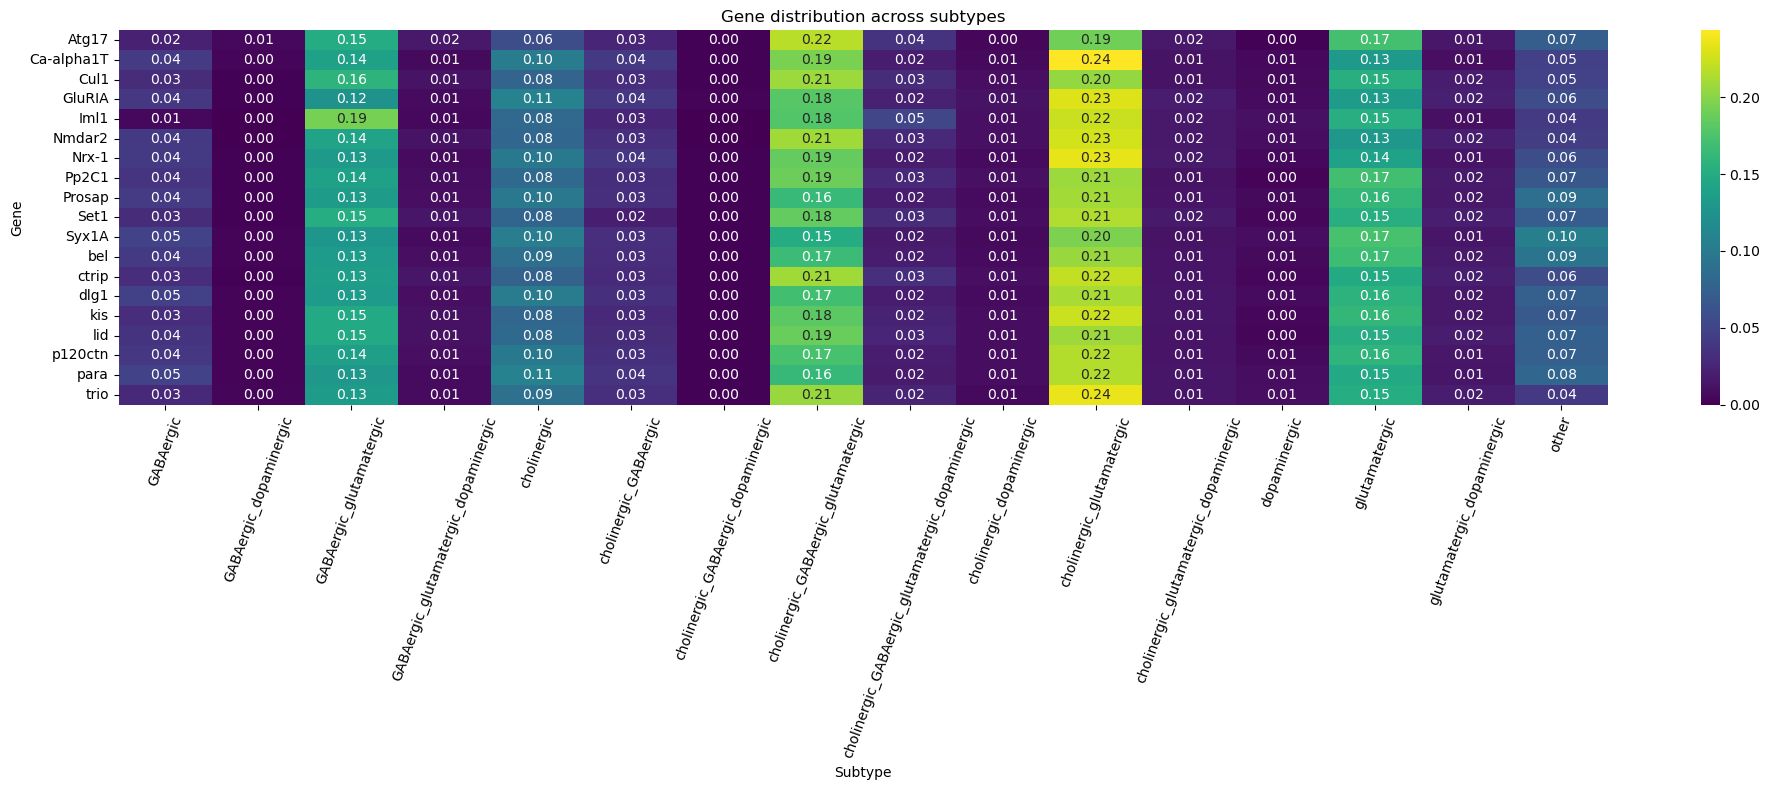

In [19]:
# 2. Fraction of gene-positive cells in each subtype
frac_gene_subtype_plot = results_subtype_df.pivot(
    index="gene",
    columns="subtype",
    values="gene_distribution"
)

plt.figure(figsize=(20, 8))
sns.heatmap(frac_gene_subtype_plot, cmap="viridis", annot=True, fmt=".2f")
plt.title("Gene distribution across subtypes")
plt.xlabel("Subtype")
plt.ylabel("Gene")
plt.xticks(rotation=70)
plt.tight_layout()
plt.savefig(f"{save_dir}/gene_distribution_nt_types.png", dpi=300)
plt.show()


### Mean Expression within Expressing Cells  

e.g how much expression within cells which express the gene


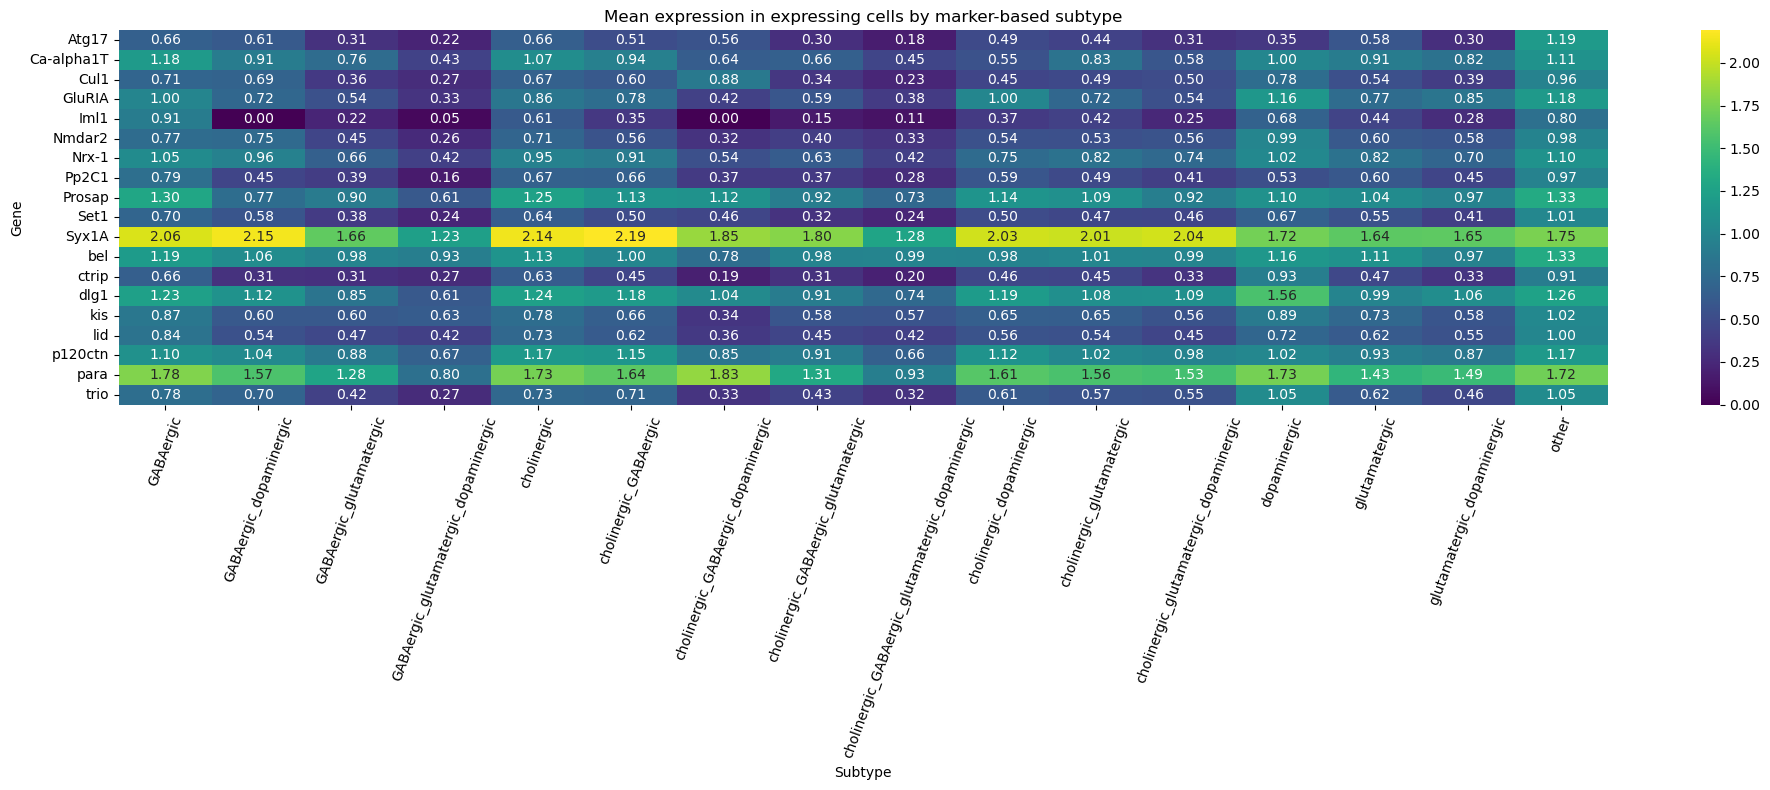

In [20]:
# 3. Mean expression in expressing cells
mean_subtype_plot = results_subtype_df.pivot(
    index="gene",
    columns="subtype",
    values="mean_expression_in_expressing_cells"
)

plt.figure(figsize=(20, 8))
sns.heatmap(mean_subtype_plot, cmap="viridis", annot=True, fmt=".2f")
plt.title("Mean expression in expressing cells by marker-based subtype")
plt.xlabel("Subtype")
plt.ylabel("Gene")
plt.xticks(rotation=70)
plt.tight_layout()
plt.savefig(f"{save_dir}/expression_within_expressing_cells.png", dpi=300)
plt.show()

GENES WHICH I HAVE TESTED IN SIDEVIEW:
    
     
**T25 C02 = kis = CHD8**    
Neuron 0.62%    
Expressing 0.68    
      
  
**T25 B09 = dlg1 = DLG4**  
Neuron 0.81%    
Expressing 1.04    
   

**T24 C09 = Set1 = SETD1A**   
Neuron 0.4%    
Expressing 0.49    
   

**T25 B02 = Prosap = SHANK3**   
Neuron 0.83%   
Expressing 1.06   
   

**T25 C03 = p120ctn = CTNND2**  
Neuron 0.79%    
Expressing 0.99   





### GENES WHICH I CAN TEST (LINES R FINE) WHICH I HAVE NOT YET TESTED   
  
DDX3X	T21 B02	22	2	T27 A01	VALIUM22-EGFP.RNAi.1}attP2  = bel  
  
NRXN1	T21 B09	20	2	T21 A08	VALIUM20-mCherry.RNAi}attP2  = Nrx-1  
  
CUL1	T24 C01	22	2	T27 A01	VALIUM22-EGFP.RNAi.1}attP2  = Cul1
  
TRIO	T24 C08	20	2	T21 A08	VALIUM20-mCherry.RNAi}attP2  =  trio  
  
DEPDC5	T25 C01	20	40	T25 B08	VALIUM20-EGFP.RNAi.4}attP40 = Iml1  
  
TRIP12	T25 C07	20	2	T21 A08	VALIUM20-mCherry.RNAi}attP2  =  ctrip



### LOOK AT THE DISTRIBUTION OF NRX1 EXPRESSION WITHIN EXPRESSING ELAV NEURONS

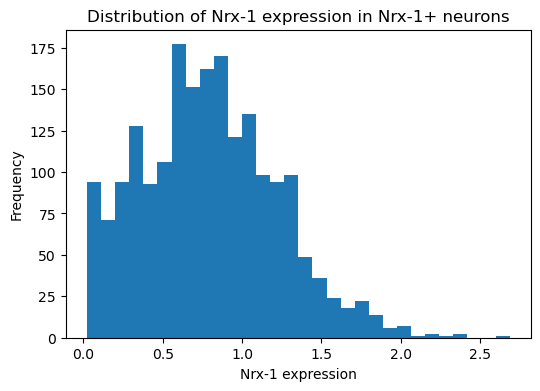

In [21]:
neuron_data = adata[adata.obs["cell_type"] == "neuron"].copy()

nrx1_neurons = neuron_data[neuron_data[:, "Nrx-1"].X.toarray().flatten() > 0].copy()

nrx1_expr = nrx1_neurons[:, "Nrx-1"].X.toarray().flatten()

plt.figure(figsize=(6, 4))
plt.hist(nrx1_expr, bins=30)
plt.xlabel("Nrx-1 expression")
plt.ylabel("Frequency")
plt.title("Distribution of Nrx-1 expression in Nrx-1+ neurons")
plt.show()



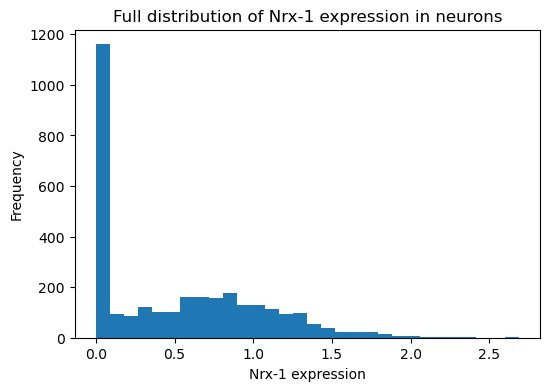

In [22]:
nrx1_expr_all = neuron_data[:, "Nrx-1"].X.toarray().flatten()

plt.figure(figsize=(6, 4))
plt.hist(nrx1_expr_all, bins=30)
plt.xlabel("Nrx-1 expression")
plt.ylabel("Frequency")
plt.title("Full distribution of Nrx-1 expression in neurons")
plt.show()